In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re



In [3]:
df = pd.read_csv(r'C:\Users\ceren\OneDrive\Desktop\job_project\clean_jobs.csv')

print(df.head())
print(df.columns)



   id            title    company           location  \
0   1     Data Analyst       Meta       New York, NY   
1   2     Data Analyst       Meta  San Francisco, CA   
2   3     Data Analyst       Meta    Los Angeles, CA   
3   4     Data Analyst       Meta     Washington, DC   
4   5  Data Analyst II  Pinterest        Chicago, IL   

                                                link    source date_posted  \
0  https://www.linkedin.com/jobs/view/data-analys...  LinkedIn  2025-04-14   
1  https://www.linkedin.com/jobs/view/data-analys...  LinkedIn  2025-04-14   
2  https://www.linkedin.com/jobs/view/data-analys...  LinkedIn  2025-04-14   
3  https://www.linkedin.com/jobs/view/data-analys...  LinkedIn  2025-04-14   
4  https://www.linkedin.com/jobs/view/data-analys...  LinkedIn  2025-04-16   

   work_type  employment_type  \
0        NaN              NaN   
1        NaN              NaN   
2        NaN              NaN   
3        NaN              NaN   
4        NaN              NaN

In [4]:
# önce description'ı string yap
df["description"] = df["description"].astype(str)

skills = ["python", "sql", "excel", "power bi", "tableau", "spark"]

# normal skill'ler
for skill in skills:
    df[skill] = df["description"].str.lower().str.contains(skill)

# R için özel
df["r"] = df["description"].str.lower().apply(lambda x: bool(re.search(r"\br\b", x)))

df.head()

,id,title,company,location,link,source,date_posted,work_type,employment_type,description,python,sql,excel,power bi,tableau,spark,r
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...,True,True,False,False,True,False,True
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...,True,True,False,False,True,False,True
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...,True,True,False,False,True,False,True
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...,True,True,False,False,True,False,True
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,NaN,NaN,About Pinterest\n\nMillions of people around t...,True,True,False,False,False,False,False


In [5]:
skills_all = ["python", "sql", "excel", "power bi", "tableau", "r", "spark"]

skill_counts = df[skills_all].sum().sort_values(ascending=False)

print(skill_counts)

sql         759
python      700
excel       491
tableau     273
r           253
spark       232
power bi    212
dtype: int64


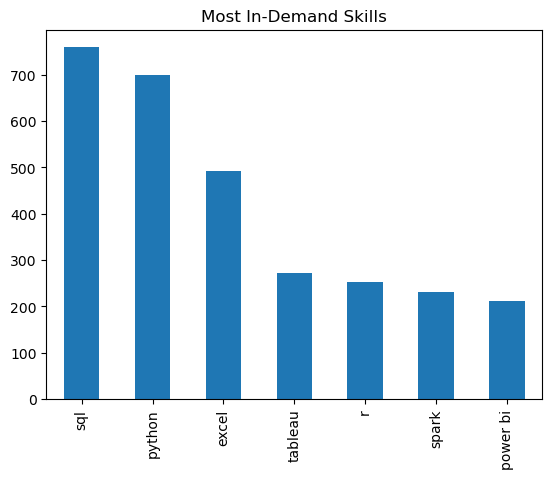

In [6]:
skill_counts.plot(kind="bar")
plt.title("Most In-Demand Skills")
plt.show()

In [7]:
df["junior"] = df["description"].str.lower().str.contains("junior|entry|0-2|graduate")

df["junior"].value_counts()

junior
False    888
True     160
Name: count, dtype: int64

In [8]:
skill_counts = df[skills_all].sum()    #hangi teknoloji hangi ilanda ne kadar % var
skill_percent = (skill_counts / len(df)) * 100
print(skill_percent)

python      66.793893
sql         72.423664
excel       46.851145
power bi    20.229008
tableau     26.049618
r           24.141221
spark       22.137405
dtype: float64


In [9]:
user_skills = ["python", "sql"]

In [10]:
#match skoru
matched = skill_percent[user_skills].sum()
total = skill_percent.sum()

score = (matched / total) * 100

print(f"Job Readiness Score: %{round(score,2)}")

missing_skills = [skill for skill in skills_all if skill not in user_skills]

missing_sorted = skill_percent[missing_skills].sort_values(ascending=False)

print("\nEksik ama önemli skill’ler:")
print(missing_sorted.head(5))

Job Readiness Score: %49.97

Eksik ama önemli skill’ler:
excel       46.851145
tableau     26.049618
r           24.141221
spark       22.137405
power bi    20.229008
dtype: float64


In [11]:
salary_df = pd.read_csv(r'C:\Users\ceren\OneDrive\Desktop\job_project\Data Science Jobs Salaries.csv')
print(salary_df.columns)
salary_df.head()

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021e,EN,FT,Data Science Consultant,54000,EUR,64369,DE,50,DE,L
1,2020,SE,FT,Data Scientist,60000,EUR,68428,GR,100,US,L
2,2021e,EX,FT,Head of Data Science,85000,USD,85000,RU,0,RU,M
3,2021e,EX,FT,Head of Data,230000,USD,230000,RU,50,RU,L
4,2021e,EN,FT,Machine Learning Engineer,125000,USD,125000,US,100,US,S


In [12]:
salary_df = salary_df[["job_title", "salary_in_usd"]]
salary_avg = salary_df.groupby("job_title")["salary_in_usd"].mean()
salary_avg = salary_avg.sort_values(ascending=False)

print(salary_avg.head(10))

job_title
Financial Data Analyst                450000.000000
Applied Machine Learning Scientist    423000.000000
Principal Data Engineer               392500.000000
Head of Data                          232500.000000
Principal Data Scientist              225097.800000
Director of Data Science              197751.500000
ML Engineer                           180655.333333
Machine Learning Scientist            180500.000000
Data Architect                        180000.000000
Principal Data Analyst                170000.000000
Name: salary_in_usd, dtype: float64


In [13]:
def normalize_title(title):
    title = str(title).lower()
    if "data analyst" in title:
        return "Data Analyst"
    elif "data scientist" in title:
        return "Data Scientist"
    elif "engineer" in title:
        return "Machine Learning Engineer"
    else:
        return "Other"

df["normalized_title"] = df["title"].apply(normalize_title)

salary_df = salary_df[["job_title", "salary_in_usd"]]

salary_avg = salary_df.groupby("job_title")["salary_in_usd"].mean()

skill_percent = (skill_counts / len(df)) * 100
salary_avg = salary_avg.fillna(0)

In [14]:
df["avg_salary"] = df["normalized_title"].map(salary_avg)

In [15]:
df[["title", "normalized_title", "avg_salary"]].head()

,title,normalized_title,avg_salary
0,Data Analyst,Data Analyst,69329.15
1,Data Analyst,Data Analyst,69329.15
2,Data Analyst,Data Analyst,69329.15
3,Data Analyst,Data Analyst,69329.15
4,Data Analyst II,Data Analyst,69329.15
